<a href="https://colab.research.google.com/github/LtFordo/SCY1101_Precios_Consumidor/blob/main/ProyectoProgramaci%C3%B3nCienciaDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!git clone https://github.com/LtFordo/SCY1101_Precios_Consumidor

fatal: destination path 'SCY1101_Precios_Consumidor' already exists and is not an empty directory.


In [9]:
# ===============================
# LIBRERÍAS PRINCIPALES
# ===============================

import pandas as pd          # Manipulación de datos
import numpy as np           # Operaciones numéricas


# Herramientas de Scikit-Learn para transformaciones profesionales
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [10]:
# ===============================
# CARGA DEL DATASET
# ===============================

# Cargar el dataset desde la carpeta /data

# Cargar el dataset
df = pd.read_csv('../data/precio_consumidor_arica_parinacota.csv')
# Mostrar primeras filas

df.head()

,Anio,Mes,Semana,Fecha inicio,Fecha termino,ID region,Region,Sector,Tipo de punto monitoreo,Grupo,Producto,Unidad,Precio minimo,Precio maximo,Precio promedio,Rango_precio
0,2025.0,1.0,1.0,2024-12-30,2025-01-03,15.0,Región de Arica y Parinacota,Arica,Carnicería,Carne bovina,Abastero,$/kilo,8499.0,8799.0,8599.0,300.0
1,2025.0,1.0,1.0,2024-12-30,2025-01-03,15.0,Región de Arica y Parinacota,Arica,Carnicería,Carne bovina,Asado Carnicero,$/kilo,7999.0,7999.0,7999.0,0.0
2,2025.0,1.0,1.0,2024-12-30,2025-01-03,15.0,Región de Arica y Parinacota,Arica,Carnicería,Carne bovina,Asado de tira,$/kilo,10299.0,10299.0,10299.0,0.0
3,2025.0,1.0,1.0,2024-12-30,2025-01-03,15.0,Región de Arica y Parinacota,Arica,Carnicería,Carne bovina,Estomaguillo (Tapabarriga),$/kilo,7999.0,7999.0,7999.0,0.0
4,2025.0,1.0,1.0,2024-12-30,2025-01-03,15.0,Región de Arica y Parinacota,Arica,Carnicería,Carne bovina,Ganso,$/kilo,8499.0,8799.0,8649.0,300.0


In [11]:
# =====================================
# CORRECCIÓN DE COLUMNAS REDUNDANTES
# =====================================
# Eliminación columnas del año, id región y región
df = df.drop(columns=['Anio', 'ID region', 'Region'])

# Traspaso del dataset al que se trabajará para no tener que cargar todo el
# archivo nuevamente ante posibles errores del procesado
df = df.copy()

# Presentación del dataset con la primera corrección
df.head()

,Mes,Semana,Fecha inicio,Fecha termino,Sector,Tipo de punto monitoreo,Grupo,Producto,Unidad,Precio minimo,Precio maximo,Precio promedio,Rango_precio
0,1.0,1.0,2024-12-30,2025-01-03,Arica,Carnicería,Carne bovina,Abastero,$/kilo,8499.0,8799.0,8599.0,300.0
1,1.0,1.0,2024-12-30,2025-01-03,Arica,Carnicería,Carne bovina,Asado Carnicero,$/kilo,7999.0,7999.0,7999.0,0.0
2,1.0,1.0,2024-12-30,2025-01-03,Arica,Carnicería,Carne bovina,Asado de tira,$/kilo,10299.0,10299.0,10299.0,0.0
3,1.0,1.0,2024-12-30,2025-01-03,Arica,Carnicería,Carne bovina,Estomaguillo (Tapabarriga),$/kilo,7999.0,7999.0,7999.0,0.0
4,1.0,1.0,2024-12-30,2025-01-03,Arica,Carnicería,Carne bovina,Ganso,$/kilo,8499.0,8799.0,8649.0,300.0


In [12]:
# ===============================
# EXPLORACIÓN GENERAL
# ===============================

# Información general del dataset
df.info()

# Estadísticas descriptivas
df.describe()

# Conteo de valores nulos por columna
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 13753 entries, 0 to 13752
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Mes                      13050 non-null  float64
 1   Semana                   13046 non-null  float64
 2   Fecha inicio             12815 non-null  str    
 3   Fecha termino            12827 non-null  str    
 4   Sector                   13081 non-null  str    
 5   Tipo de punto monitoreo  13043 non-null  str    
 6   Grupo                    13047 non-null  str    
 7   Producto                 13076 non-null  str    
 8   Unidad                   13058 non-null  str    
 9   Precio minimo            12797 non-null  float64
 10  Precio maximo            12812 non-null  float64
 11  Precio promedio          13753 non-null  float64
 12  Rango_precio             11928 non-null  float64
dtypes: float64(6), str(7)
memory usage: 1.4 MB


Mes                         703
Semana                      707
Fecha inicio                938
Fecha termino               926
Sector                      672
Tipo de punto monitoreo     710
Grupo                       706
Producto                    677
Unidad                      695
Precio minimo               956
Precio maximo               941
Precio promedio               0
Rango_precio               1825
dtype: int64

In [13]:
# ===============================
# DETECCIÓN DE DUPLICADOS
# ===============================

# Contar filas duplicadas
df.duplicated().sum()

# Eliminar duplicados
df = df.drop_duplicates()

In [14]:
# ===============================
# MANEJO DE NULOS
# ===============================

# Columnas numéricas
# 'Anio' y 'ID region' fueron eliminadas de 'raw' y 'df'
num_cols = ["Mes","Semana","Precio minimo","Precio maximo","Precio promedio", "Rango_precio"]

# Columnas categóricas
# 'Region' fue eliminada de 'raw' y 'df'
cat_cols = ["Sector","Tipo de punto monitoreo","Grupo","Producto","Unidad"]

# Imputador numérico (media)
num_imputer = SimpleImputer(strategy="mean")

# Imputador categórico (valor más frecuente)
cat_imputer = SimpleImputer(strategy="most_frequent")

In [15]:
# ===============================
# CORRECCIÓN DE TIPOS
# ===============================

# Convertir fechas
df["Fecha inicio"] = pd.to_datetime(df["Fecha inicio"], errors="coerce")
df["Fecha termino"] = pd.to_datetime(df["Fecha termino"], errors="coerce")


# Reemplazar coma decimal y convertir a número
df["Precio minimo"] = df["Precio minimo"].astype(str).str.replace(",", ".")
df["Precio maximo"] = df["Precio maximo"].astype(str).str.replace(",", ".")
df["Precio promedio"] = df["Precio promedio"].astype(str).str.replace(",", ".")

# Convertir precios mínimos y máximos
df["Precio minimo"] = pd.to_numeric(df["Precio minimo"], errors="coerce")
df["Precio maximo"] = pd.to_numeric(df["Precio maximo"], errors="coerce")
df["Precio promedio"] = pd.to_numeric(df["Precio promedio"], errors="coerce")

In [16]:
# ===============================
# DETECCIÓN DE OUTLIERS
# ===============================

# Método IQR
Q1 = df["Precio promedio"].quantile(0.25)
Q3 = df["Precio promedio"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores extremos y asegurar que es una copia independiente
df = df[(df["Precio promedio"] >= limite_inferior) &
        (df["Precio promedio"] <= limite_superior)].copy()

In [17]:
# ===============================
# FEATURE ENGINEERING
# ===============================

# Rango de precios
df["Rango_precio"] = df["Precio maximo"] - df["Precio minimo"]

In [18]:
# ===============================
# PIPELINE DE TRANSFORMACIÓN
# ===============================

# Escalado de variables numéricas
scaler = StandardScaler()

# One Hot Encoding para categóricas
encoder = OneHotEncoder(handle_unknown="ignore")

# Transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", num_imputer),
            ("scaler", scaler)
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", cat_imputer),
            ("encoder", encoder)
        ]), cat_cols)
    ]
)

# Pipeline final
pipeline = Pipeline([
    ("preprocessor", preprocessor)
])

In [19]:
# ===============================
# APLICAR TRANSFORMACIONES
# ===============================

X_processed = pipeline.fit_transform(df)

# Obtener los nombres de las columnas transformadas
# Primero, obtener los nombres de las características numéricas transformadas
num_feature_names = num_cols # Asumen que el scaler no cambia los nombres

# Luego, obtener los nombres de las características categóricas one-hot encoded
cat_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)

# Combinar todos los nombres de las características
all_feature_names = list(num_feature_names) + list(cat_feature_names)

# Convertir X_processed a un DataFrame de Pandas para visualización
X_processed_df = pd.DataFrame(X_processed.toarray(), columns=all_feature_names)

# Mostrar las primeras filas del DataFrame procesado
display(X_processed_df.head())

,Mes,Semana,Precio minimo,Precio maximo,Precio promedio,Rango_precio,Sector_ Arica,Sector_ None,Sector_Arica,Tipo de punto monitoreo_ Carnicería,...,Unidad_$/Caja de 1 Litro,Unidad_$/bandeja 12 unidades,Unidad_$/bolsa 1 kilo,Unidad_$/bolsa 800 grs,Unidad_$/botella 900 ml,Unidad_$/envase 400 gramos,Unidad_$/kilo,Unidad_$/pan de 250 gramos,Unidad_$/pote 500 gramos,Unidad_$/unidad
0,-1.539874,-1.666142,0.028832,-0.003591,2.994523,-0.017321,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.539874,-1.666142,0.019188,-0.016185,2.701443,-0.021104,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.539874,-1.666142,0.019188,-0.016185,2.701443,-0.021104,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.539874,-1.666142,0.028832,-0.003591,3.018946,-0.017321,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.539874,-1.666142,0.019188,-0.009888,2.766572,-0.016059,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [20]:
# ===============================
# EXPLORACIÓN GENERAL
# ===============================

# Corroboración de que no hayan nulos, principal problema con el dataset
# completo.

# Información general del dataset
X_processed_df.info()

# Estadísticas descriptivas
X_processed_df.describe()

# Conteo de valores nulos por columna
X_processed_df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12417 entries, 0 to 12416
Columns: 409 entries, Mes to Unidad_$/unidad
dtypes: float64(409)
memory usage: 38.7 MB


Mes                           0
Semana                        0
Precio minimo                 0
Precio maximo                 0
Precio promedio               0
                             ..
Unidad_$/envase 400 gramos    0
Unidad_$/kilo                 0
Unidad_$/pan de 250 gramos    0
Unidad_$/pote 500 gramos      0
Unidad_$/unidad               0
Length: 409, dtype: int64

Visualización de la Variable Más Representativa: Precio Promedio
Se ha elegido 'Precio promedio' como la variable más representativa para visualizar la distribución de precios en el dataset. La razón principal es que esta columna es el resultado de un proceso de limpieza, corrección de tipos y tratamiento de valores atípicos, lo que la convierte en el indicador más fiable y central del comportamiento de los precios de los productos en el mercado.

Un histograma es la representación gráfica más adecuada para entender la distribución de una variable numérica continua, como el precio promedio. Nos permitirá identificar:

Rango de precios: Cuáles son los valores mínimos y máximos.
Tendencia central: Dónde se concentra la mayoría de los precios.
Forma de la distribución: Si es simétrica, asimétrica, bimodal, etc.
Posibles anomalías: Precios inusualmente altos o bajos que aún persistieron después del tratamiento de outliers (aunque en menor medida).

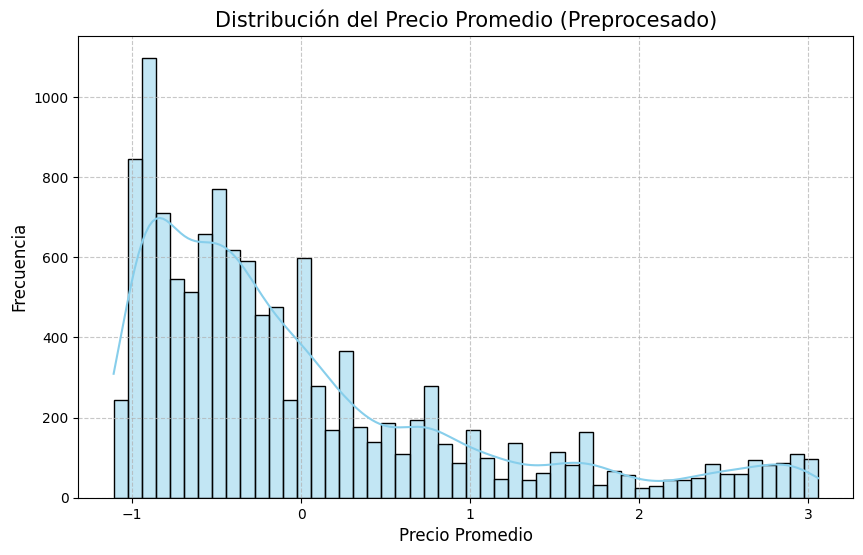

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# VISUALIZACIÓN DE LA VARIABLE MÁS REPRESENTATIVA
# ===============================

# Se crea una figura con un tamaño específico para mejorar la legibilidad
plt.figure(figsize=(10, 6))

# Se genera un histograma del 'Precio promedio' utilizando seaborn.
# 'kde=True' añade una estimación de la densidad del kernel para suavizar la distribución.
# 'bins=50' define el número de barras en el histograma para una visualización detallada.
# 'color="skyblue"' establece el color de las barras.
sns.histplot(X_processed_df['Precio promedio'], kde=True, bins=50, color='skyblue')

# Se añade un título descriptivo al gráfico.
plt.title('Distribución del Precio Promedio (Preprocesado)', fontsize=15)

# Se etiquetan los ejes para claridad.
plt.xlabel('Precio Promedio', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Se añade una cuadrícula al gráfico para facilitar la lectura de los valores.
plt.grid(True, linestyle='--', alpha=0.7)

# Se muestra el gráfico.
plt.show()

In [22]:
# ===============================
# GUARDAR DATASET PROCESADO
# ===============================

# Ruta y nombre del archivo corregido
output_file_path = 'SCY1101_Precios_Consumidor/data/precio_consumidor_arica_parinacota_corregido.csv'

# Guardar el DataFrame procesado a un archivo CSV
X_processed_df.to_csv(output_file_path, index=False)

print(f"El dataset corregido ha sido guardado en: {output_file_path}")

El dataset corregido ha sido guardado en: SCY1101_Precios_Consumidor/data/precio_consumidor_arica_parinacota_corregido.csv
